In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pytz

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

### 1. Preparing the data

In [10]:
df = pd.read_csv("Nairobi AirQuality.csv", sep=";", on_bad_lines="skip")
df.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P2,22.60
1,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P1,25.20
2,4930,pms5003,3981,-1.269,36.819,2025-12-01T00:00:00.931399+00:00,P0,15.00
3,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,humidity,73.60
4,4931,DHT22,3981,-1.269,36.819,2025-12-01T00:00:18.348581+00:00,temperature,18.10


I will be using a function for this one

In [80]:
def wrangle(filepath):

    #Load the data
    df = pd.read_csv(filepath, sep=";", on_bad_lines="skip")
    
    
    #Filter for PM2.5 readings only
    df = df[df["value_type"] == "P2"]
    
    #Parse timestamp and set as index
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, format='ISO8601')
    df = df.set_index("timestamp")
    
    #Keep only the PM2.5 value column
    df = df[["value"]]
    
    #Renaming
    df.columns = ["pm2.5"]
    
    #Sort by time
    df = df.sort_index()

    #Localize timezone
    df.index = df.index.tz_convert("Africa/Nairobi")

    #Convert to float, coerce bad values to NaN
    df["pm2.5"] = pd.to_numeric(df["pm2.5"], errors="coerce")

    #Removing outliers
    df = df[df["pm2.5"] < 500]

    #Resample to 1h window and ffill any missing values
    df = df["pm2.5"].resample("1h").mean().ffill().to_frame()

    #Add the lag feature
    df["pm2.5_L1"] = df["pm2.5"].shift(1)

    #Drop NaN  rows
    df.dropna(inplace=True)
    
    return df

In [81]:
df = wrangle("Nairobi AirQuality.csv")
df.head()

,pm2.5,pm2.5_L1
timestamp,,
2025-12-01 04:00:00+03:00,18.820000,24.144906
2025-12-01 05:00:00+03:00,28.562500,18.820000
2025-12-01 06:00:00+03:00,34.902381,28.562500
2025-12-01 07:00:00+03:00,32.240385,34.902381
2025-12-01 08:00:00+03:00,24.078571,32.240385


In [26]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 30884 entries, 2025-12-01 03:00:00.931399+03:00 to 2026-01-01 02:59:28.916949+03:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm2.5   30877 non-null  float64
dtypes: float64(1)
memory usage: 482.6 KB


In [60]:
df.shape

(744, 1)

The timestamps are stored in Universal Coordinated Timer(UTC) so I localized them to the Nairobi timezone

In [14]:
df.index[:5]

DatetimeIndex(['2025-12-01 00:00:00.931399+00:00',
                      '2025-12-01 00:02:01+00:00',
               '2025-12-01 00:02:26.384604+00:00',
                      '2025-12-01 00:05:26+00:00',
                      '2025-12-01 00:05:26+00:00'],
              dtype='datetime64[us, UTC]', name='timestamp', freq=None)

In [ ]:
#localizing
df.index.tz_convert("Africa/Nairobi")[:5]

DatetimeIndex(['2025-12-01 03:00:00.931399+03:00',
                      '2025-12-01 03:02:01+03:00',
               '2025-12-01 03:02:26.384604+03:00',
                      '2025-12-01 03:05:26+03:00',
                      '2025-12-01 03:05:26+03:00'],
              dtype='datetime64[us, Africa/Nairobi]', name='timestamp', freq=None)

### 2. Exploratory Data Analysis(EDA)

<Axes: title={'center': 'Distribution of PM2.5 Reaadings'}>

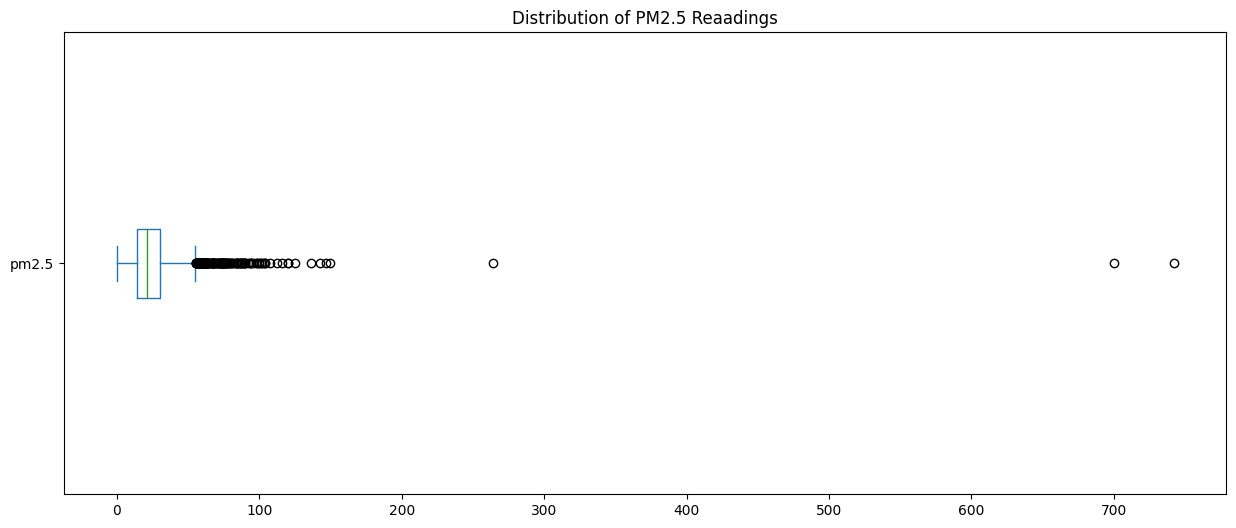

In [40]:
#I decided to check the distribution of PM2.5 readings to see if there are any outliers using a boxplot
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].plot(kind="box", vert=False, title="Distribution of PM2.5 Reaadings", ax=ax)

After some research, the hazardous level readings are only up to around 500, so the figures above that are probably wrong

In [41]:
df = df[df["pm2.5"] < 500]

In [72]:
df.isna().sum()

pm2.5    0
dtype: int64

In [43]:
df.shape

(30875, 1)

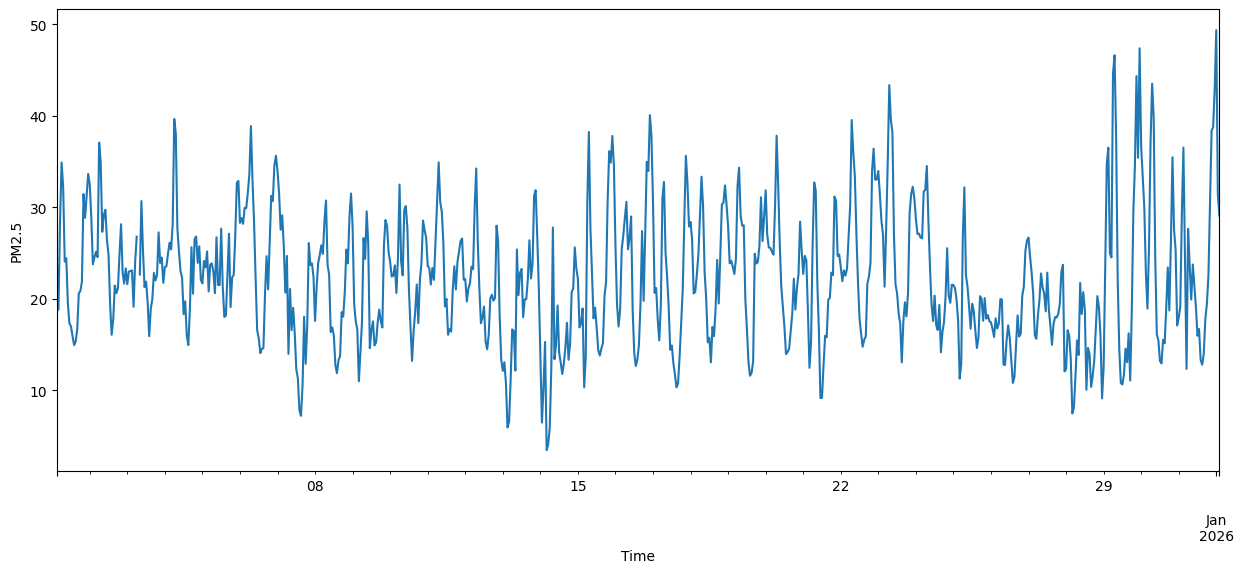

In [61]:
#Time Series line plot
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].plot(xlabel="Time", ylabel="PM2.5", ax=ax);

There are no sudden breaks in the line plot which confirms no missing data.

In [ ]:
df["pm2.5"].resample("1h")

In [69]:
df = df["pm2.5"].resample("1h").mean().ffill().to_frame().head()

In [52]:
df.isna().sum()

pm2.5    0
dtype: int64

In [64]:
#Rolling Average to smooth the data and see any general trend
df["pm2.5"].rolling(168).mean().tail()

timestamp
2025-12-31 22:00:00+03:00    20.488949
2025-12-31 23:00:00+03:00    20.616335
2026-01-01 00:00:00+03:00    20.782137
2026-01-01 01:00:00+03:00    20.842667
2026-01-01 02:00:00+03:00    20.897353
Freq: h, Name: pm2.5, dtype: float64

In [74]:
df["pm2.5"].rolling(168).mean().isna().sum()

np.int64(167)

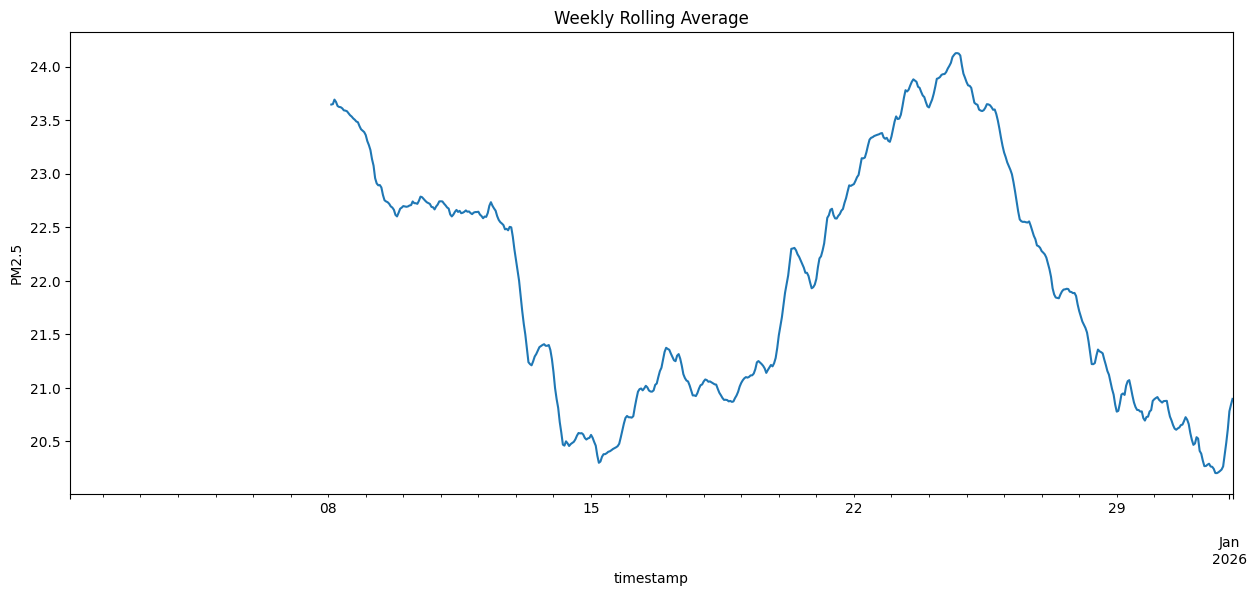

In [75]:
fig, ax = plt.subplots(figsize=(15, 6))
df["pm2.5"].rolling(168).mean().plot(ax=ax, ylabel="PM2.5", title="Weekly Rolling Average");

In [79]:
#Creating the Lag feature, basically the new column where the data is shifted by a lag of 1
df["pm2.5_L1"] = df["pm2.5"].shift(1)
df.dropna().head()

,pm2.5,pm2.5_L1
timestamp,,
2025-12-01 04:00:00+03:00,18.820000,24.144906
2025-12-01 05:00:00+03:00,28.562500,18.820000
2025-12-01 06:00:00+03:00,34.902381,28.562500
2025-12-01 07:00:00+03:00,32.240385,34.902381
2025-12-01 08:00:00+03:00,24.078571,32.240385


In [ ]:
#Now checking whether there is a relationship between the feature and the target.
df.corr()

,pm2.5,pm2.5_L1
pm2.5,1.00000,0.79145
pm2.5_L1,0.79145,1.00000


We can see there is strong positive correlation. Bacisally, there seems to be a relationship btn what happens at time step t, and timestep t-1.

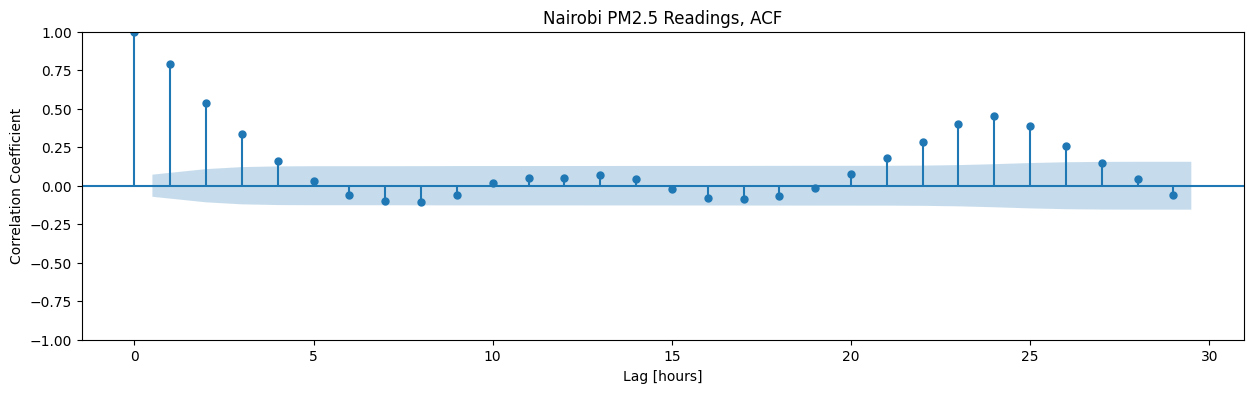

In [84]:
#ACF plot
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df["pm2.5"], ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, ACF");

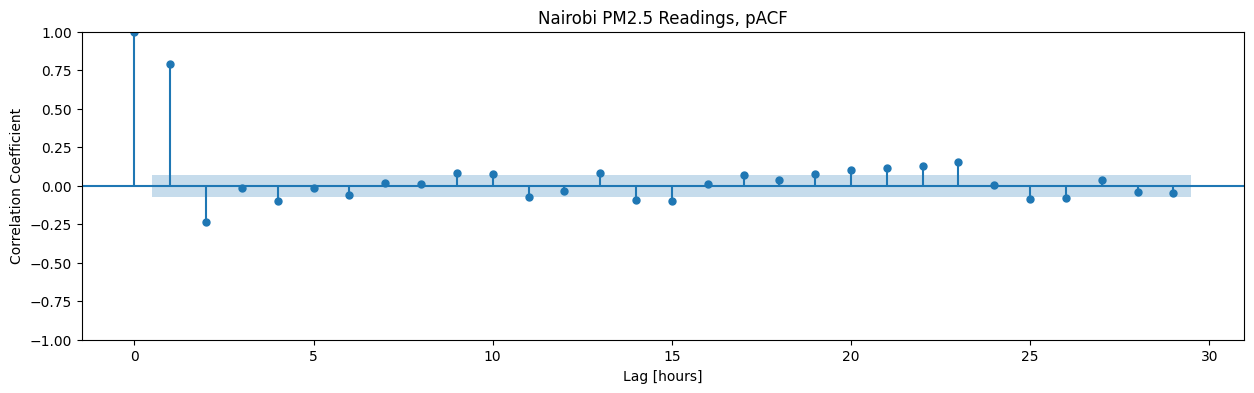

In [ ]:
#PACF plot
fig, ax = plt.subplots(figsize=(15, 4))
plot_pacf(df["pm2.5"], ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Nairobi PM2.5 Readings, pACF");